# CSL7110 Assignment 3  
## Recommender Systems: Content-Based and Collaborative Filtering

**Name:** Ashish Sinha  
**Roll No:** M25DE1047

## Setup and Imports

In [1]:
# Uncomment only if needed
!pip install -r ../requirements.txt


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import math
import random
import warnings
from collections import defaultdict
from pathlib import Path


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession, functions as F, Window
from pyspark.sql.types import DoubleType
from pyspark.storagelevel import StorageLevel

from pyspark.ml import Pipeline
from pyspark.ml.feature import HashingTF, IDF
from pyspark.ml.linalg import DenseVector, SparseVector, VectorUDT
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

## Spark Session Configuration

In [3]:
spark = (
    SparkSession.builder
    .appName("CSL7110_Assignment3_MacSafe")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "64")
    .config("spark.default.parallelism", "64")
    .config("spark.driver.memory", "6g")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/18 22:08:37 WARN Utils: Your hostname, ASHISHs-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.6 instead (on interface en0)
26/03/18 22:08:37 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/18 22:08:38 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.1


## Dataset Configuration

In [4]:
#DATA_DIR = "./dataset/ml-latest"   # change if needed
project_root = Path.cwd().resolve().parent
BASE_DIR = project_root / "dataset" / "ml-latest-small"
MOVIES_FILE = f"file://{(BASE_DIR / 'movies.csv').resolve()}"
RATINGS_FILE = f"file://{(BASE_DIR / 'ratings.csv').resolve()}"

TOP_K = 5
POSITIVE_THRESHOLD = 4.0

# local safety knobs
MAX_EVAL_USERS = 30
MAX_CF_USERS = 800
MAX_CF_MOVIES = 1200
MAX_LOCAL_MOVIES = 5000
MAX_LOCAL_RATINGS = 150000
MAX_NEURAL_ROWS = 80000

print("Movies path :", MOVIES_FILE)
print("Ratings path:", RATINGS_FILE)

Movies path : file:///Users/ashishsinha/Documents/Study/MTech/Sm02/MLwDE/Assignment03/gihubrepo/iitj_m25de1047_mlbd_Assignment03/dataset/ml-latest-small/movies.csv
Ratings path: file:///Users/ashishsinha/Documents/Study/MTech/Sm02/MLwDE/Assignment03/gihubrepo/iitj_m25de1047_mlbd_Assignment03/dataset/ml-latest-small/ratings.csv


## Load Dataset with Spark

In [5]:
movies_raw = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(MOVIES_FILE)
)

ratings_raw = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(RATINGS_FILE)
)

print("Movies rows :", movies_raw.count())
print("Ratings rows:", ratings_raw.count())

movies_raw.show(5, truncate=False)
ratings_raw.show(5, truncate=False)

Movies rows : 9742
Ratings rows: 100836
+-------+----------------------------------+-------------------------------------------+
|movieId|title                             |genres                                     |
+-------+----------------------------------+-------------------------------------------+
|1      |Toy Story (1995)                  |Adventure|Animation|Children|Comedy|Fantasy|
|2      |Jumanji (1995)                    |Adventure|Children|Fantasy                 |
|3      |Grumpier Old Men (1995)           |Comedy|Romance                             |
|4      |Waiting to Exhale (1995)          |Comedy|Drama|Romance                       |
|5      |Father of the Bride Part II (1995)|Comedy                                     |
+-------+----------------------------------+-------------------------------------------+
only showing top 5 rows
+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|1     |1      |4.0   |964982703|

## Preprocessing

In [6]:
movies = (
    movies_raw
    .withColumn(
        "genres_clean",
        F.when(
            F.col("genres").isNull() | (F.col("genres") == "(no genres listed)"),
            F.lit("Unknown")
        ).otherwise(F.col("genres"))
    )
    .withColumn(
        "year",
        F.when(
            F.col("title").rlike(r"\((\d{4})\)\s*$"),
            F.regexp_extract(F.col("title"), r"\((\d{4})\)\s*$", 1).cast("int")
        ).otherwise(F.lit(None).cast("int"))
    )
)

movie_stats = (
    ratings_raw
    .groupBy("movieId")
    .agg(
        F.count("*").alias("movie_rating_count"),
        F.avg("rating").alias("movie_avg_rating")
    )
)

user_stats = (
    ratings_raw
    .groupBy("userId")
    .agg(
        F.count("*").alias("user_rating_count"),
        F.avg("rating").alias("user_avg_rating")
    )
)

global_mean_rating = ratings_raw.agg(F.avg("rating").alias("avg")).first()["avg"]

movies = (
    movies.join(movie_stats, on="movieId", how="left")
    .fillna({
        "movie_rating_count": 0,
        "movie_avg_rating": float(global_mean_rating)
    })
)

movies.persist(StorageLevel.MEMORY_AND_DISK)
user_stats.persist(StorageLevel.MEMORY_AND_DISK)

movies.show(5, truncate=False)

+-------+----------------------------------+-------------------------------------------+-------------------------------------------+----+------------------+------------------+
|movieId|title                             |genres                                     |genres_clean                               |year|movie_rating_count|movie_avg_rating  |
+-------+----------------------------------+-------------------------------------------+-------------------------------------------+----+------------------+------------------+
|1      |Toy Story (1995)                  |Adventure|Animation|Children|Comedy|Fantasy|Adventure|Animation|Children|Comedy|Fantasy|1995|215               |3.9209302325581397|
|2      |Jumanji (1995)                    |Adventure|Children|Fantasy                 |Adventure|Children|Fantasy                 |1995|110               |3.4318181818181817|
|3      |Grumpier Old Men (1995)           |Comedy|Romance                             |Comedy|Romance                  

In [7]:
# Random split is cheaper than full global sort on a laptop
train_ratings, test_ratings = ratings_raw.randomSplit([0.8, 0.2], seed=42)

train_users = train_ratings.select("userId").distinct()
train_movies = train_ratings.select("movieId").distinct()

test_ratings_in_train = (
    test_ratings
    .join(train_users, on="userId", how="inner")
    .join(train_movies, on="movieId", how="inner")
)

print("Train ratings:", train_ratings.count())
print("Test ratings :", test_ratings.count())
print("Filtered test ratings:", test_ratings_in_train.count())

Train ratings: 80578
Test ratings : 20258
Filtered test ratings: 19437


## Common Helper Functions

In [8]:
def precision_recall_at_k(recommended_ids, relevant_ids, k=5):
    recommended_top_k = list(recommended_ids)[:k]
    relevant_set = set(relevant_ids)
    hits = len(set(recommended_top_k) & relevant_set)
    precision = hits / k if k > 0 else 0.0
    recall = hits / len(relevant_set) if len(relevant_set) > 0 else 0.0
    return precision, recall

def rmse_score(y_true, y_pred):
    if len(y_true) == 0:
        return None
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def clip_rating(x, low=0.5, high=5.0):
    return float(np.clip(x, low, high))

def to_numpy(v):
    if isinstance(v, SparseVector):
        return v.toArray()
    if isinstance(v, DenseVector):
        return np.array(v)
    return np.array(v)

In [9]:
train_seen_movies_pd = (
    train_ratings.groupBy("userId")
    .agg(F.collect_set("movieId").alias("seen_movies"))
    .limit(50000)
    .toPandas()
)
train_seen_movies = dict(zip(train_seen_movies_pd["userId"], train_seen_movies_pd["seen_movies"]))

relevant_test_pd = (
    test_ratings_in_train
    .filter(F.col("rating") >= POSITIVE_THRESHOLD)
    .groupBy("userId")
    .agg(F.collect_list("movieId").alias("relevant_movies"))
    .orderBy(F.desc(F.size("relevant_movies")))
    .limit(MAX_EVAL_USERS)
    .toPandas()
)
relevant_test_items = dict(zip(relevant_test_pd["userId"], relevant_test_pd["relevant_movies"]))
eval_users = list(relevant_test_items.keys())

print("Evaluation users:", len(eval_users))

Evaluation users: 30


# Part 1: Content-Based Filtering

## Task 1: TF-IDF Based Recommendation Using Movie Genres

In [10]:
movies_tokens = movies.withColumn("genre_tokens", F.split(F.col("genres_clean"), r"\|"))

hashing_tf = HashingTF(inputCol="genre_tokens", outputCol="raw_features", numFeatures=1024)
idf = IDF(inputCol="raw_features", outputCol="tfidf_features")

tfidf_pipeline = Pipeline(stages=[hashing_tf, idf])
tfidf_model = tfidf_pipeline.fit(movies_tokens)

movies_tfidf = tfidf_model.transform(movies_tokens).select(
    "movieId", "title", "genres_clean", "year", "movie_rating_count", "movie_avg_rating", "tfidf_features"
)

movies_tfidf.persist(StorageLevel.MEMORY_AND_DISK)
movies_tfidf.show(5, truncate=False)

+-------+----------------------------------+-------------------------------------------+----+------------------+------------------+----------------------------------------------------------------------------------------------------------------------------+
|movieId|title                             |genres_clean                               |year|movie_rating_count|movie_avg_rating  |tfidf_features                                                                                                              |
+-------+----------------------------------+-------------------------------------------+----+------------------+------------------+----------------------------------------------------------------------------------------------------------------------------+
|1      |Toy Story (1995)                  |Adventure|Animation|Children|Comedy|Fantasy|1995|215               |3.9209302325581397|(1024,[102,356,644,819,950],[2.7675720749130153,2.5250104377417038,2.684517316769487,0.93055601409

In [11]:
# Only collect a bounded movie set locally for similarity demos
popular_movie_ids = [
    r["movieId"]
    for r in movies_tfidf.orderBy(F.desc("movie_rating_count")).select("movieId").limit(MAX_LOCAL_MOVIES).collect()
]

movies_tfidf_local = (
    movies_tfidf
    .filter(F.col("movieId").isin(popular_movie_ids))
    .select("movieId", "title", "genres_clean", "year", "tfidf_features")
    .toPandas()
)

movies_tfidf_local["tfidf_np"] = movies_tfidf_local["tfidf_features"].apply(to_numpy)
movie_id_to_vec = dict(zip(movies_tfidf_local["movieId"], movies_tfidf_local["tfidf_np"]))

def cosine_np(a, b):
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return 0.0
    return float(np.dot(a, b) / denom)

def recommend_similar_movies(movie_query, top_n=5):
    if isinstance(movie_query, str):
        matched = movies_tfidf_local[movies_tfidf_local["title"].str.contains(movie_query, case=False, na=False)]
        if matched.empty:
            raise ValueError(f"No title matched: {movie_query}")
        target = matched.iloc[0]
    else:
        matched = movies_tfidf_local[movies_tfidf_local["movieId"] == int(movie_query)]
        if matched.empty:
            raise ValueError(f"movieId not found: {movie_query}")
        target = matched.iloc[0]

    rows = []
    for row in movies_tfidf_local.itertuples(index=False):
        if row.movieId == target["movieId"]:
            continue
        sim = cosine_np(target["tfidf_np"], row.tfidf_np)
        rows.append((row.movieId, row.title, row.genres_clean, row.year, sim))

    out = pd.DataFrame(rows, columns=["movieId", "title", "genres_clean", "year", "similarity_score"])
    return out.sort_values("similarity_score", ascending=False).head(top_n).reset_index(drop=True)

display(recommend_similar_movies("Toy Story", 5))

,movieId,title,genres_clean,year,similarity_score
0,4016,"Emperor's New Groove, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,2000.0,1.0
1,53121,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,2007.0,1.0
2,4886,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,2001.0,1.0
3,3754,"Adventures of Rocky and Bullwinkle, The (2000)",Adventure|Animation|Children|Comedy|Fantasy,2000.0,1.0
4,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,1999.0,1.0


## Task 2: User Profile Based Content Recommender

In [12]:
# Keep profile building Spark-heavy; collect only sampled subset for local profile vectors
train_with_tfidf = (
    train_ratings
    .join(movies_tfidf.select("movieId", "tfidf_features"), on="movieId", how="inner")
    .join(user_stats.select("userId", "user_rating_count"), on="userId", how="inner")
    .filter(F.col("user_rating_count") >= 20)
    .limit(MAX_LOCAL_RATINGS)
)

user_profile_rows = []
for row in train_with_tfidf.select("userId", "rating", "tfidf_features").toLocalIterator():
    vec = to_numpy(row["tfidf_features"])
    user_profile_rows.append((row["userId"], vec * float(row["rating"]), float(row["rating"])))

user_profile_dict = defaultdict(lambda: {"weighted_sum": None, "rating_sum": 0.0})
for uid, weighted_vec, rating in user_profile_rows:
    if user_profile_dict[uid]["weighted_sum"] is None:
        user_profile_dict[uid]["weighted_sum"] = weighted_vec.copy()
    else:
        user_profile_dict[uid]["weighted_sum"] += weighted_vec
    user_profile_dict[uid]["rating_sum"] += rating

user_profiles = {}
for uid, payload in user_profile_dict.items():
    profile = payload["weighted_sum"] / max(payload["rating_sum"], 1e-9)
    norm = np.linalg.norm(profile)
    if norm > 0:
        profile = profile / norm
    user_profiles[uid] = profile

print("User profiles created:", len(user_profiles))

User profiles created: 610


In [13]:
def recommend_content_for_user(user_id, top_n=5):
    if user_id not in user_profiles:
        return pd.DataFrame(columns=["movieId", "title", "content_score"])

    seen = set(train_seen_movies.get(user_id, []))
    user_vec = user_profiles[user_id]

    rows = []
    for row in movies_tfidf_local.itertuples(index=False):
        if row.movieId in seen:
            continue
        score = cosine_np(user_vec, row.tfidf_np)
        rows.append((row.movieId, row.title, row.genres_clean, row.year, score))

    out = pd.DataFrame(rows, columns=["movieId", "title", "genres_clean", "year", "content_score"])
    return out.sort_values("content_score", ascending=False).head(top_n).reset_index(drop=True)

sample_uid = next((u for u in eval_users if u in user_profiles), None)
if sample_uid is not None:
    display(recommend_content_for_user(sample_uid, 5))

,movieId,title,genres_clean,year,content_score
0,4956,"Stunt Man, The (1980)",Action|Adventure|Comedy|Drama|Romance|Thriller,1980.0,0.812006
1,459,"Getaway, The (1994)",Action|Adventure|Crime|Drama|Romance|Thriller,1994.0,0.798812
2,58025,Jumper (2008),Action|Adventure|Drama|Sci-Fi|Thriller,2008.0,0.751939
3,6564,Lara Croft Tomb Raider: The Cradle of Life (2003),Action|Adventure|Comedy|Romance|Thriller,2003.0,0.747089
4,55116,"Hunting Party, The (2007)",Action|Adventure|Comedy|Drama|Thriller,2007.0,0.724853


In [14]:
content_eval_rows = []
for uid in eval_users:
    if uid not in user_profiles:
        continue
    relevant_ids = relevant_test_items.get(uid, [])
    rec_df = recommend_content_for_user(uid, TOP_K)
    rec_ids = rec_df["movieId"].tolist()
    p5, r5 = precision_recall_at_k(rec_ids, relevant_ids, TOP_K)
    content_eval_rows.append((uid, p5, r5))

content_eval_df = pd.DataFrame(content_eval_rows, columns=["userId", "precision@5", "recall@5"])
content_p5 = float(content_eval_df["precision@5"].mean()) if not content_eval_df.empty else 0.0
content_r5 = float(content_eval_df["recall@5"].mean()) if not content_eval_df.empty else 0.0

print("Content-Based Precision@5:", round(content_p5, 4))
print("Content-Based Recall@5   :", round(content_r5, 4))
display(content_eval_df.head())

Content-Based Precision@5: 0.06
Content-Based Recall@5   : 0.004


,userId,precision@5,recall@5
0,414,0.0,0.000000
1,474,0.0,0.000000
2,380,0.0,0.000000
3,603,0.2,0.009091
4,610,0.2,0.009434


# Part 2: Collaborative Filtering

## Task 3: User-Based Collaborative Filtering

In [15]:
top_users = [r["userId"] for r in train_ratings.groupBy("userId").count().orderBy(F.desc("count")).limit(MAX_CF_USERS).collect()]
top_movies = [r["movieId"] for r in train_ratings.groupBy("movieId").count().orderBy(F.desc("count")).limit(MAX_CF_MOVIES).collect()]

cf_train_pd = (
    train_ratings
    .filter(F.col("userId").isin(top_users) & F.col("movieId").isin(top_movies))
    .toPandas()
)

ui_train = cf_train_pd.pivot_table(index="userId", columns="movieId", values="rating", aggfunc="mean")
ui_train = ui_train.sort_index().sort_index(axis=1)

user_means_cf = ui_train.mean(axis=1).fillna(global_mean_rating)
ui_centered = ui_train.sub(user_means_cf, axis=0).fillna(0.0)

print("Reduced user-item matrix shape:", ui_train.shape)

Reduced user-item matrix shape: (610, 1200)


In [16]:
from sklearn.metrics.pairwise import cosine_similarity

user_sim_array = cosine_similarity(ui_centered.values).copy()
np.fill_diagonal(user_sim_array, 0.0)
user_similarity = pd.DataFrame(user_sim_array, index=ui_train.index, columns=ui_train.index)

def predict_user_cf(user_id, movie_id, k=20):
    if user_id not in ui_train.index or movie_id not in ui_train.columns:
        return None

    movie_ratings = ui_train[movie_id]
    sims = user_similarity.loc[user_id]

    neighbors = pd.DataFrame({"sim": sims, "rating": movie_ratings}).dropna()
    neighbors = neighbors[neighbors["sim"] > 0].sort_values("sim", ascending=False).head(k)

    if neighbors.empty:
        return float(user_means_cf.get(user_id, global_mean_rating))

    num = ((neighbors["rating"] - user_means_cf.loc[neighbors.index]) * neighbors["sim"]).sum()
    den = neighbors["sim"].abs().sum()
    if den == 0:
        return float(user_means_cf.get(user_id, global_mean_rating))

    return float(np.clip(user_means_cf[user_id] + (num / den), 0.5, 5.0))

In [17]:
cf_test_pd = (
    test_ratings_in_train
    .filter(F.col("userId").isin(list(ui_train.index)) & F.col("movieId").isin(list(ui_train.columns)))
    .limit(50000)
    .toPandas()
)

k_values = [10, 20, 30]
user_cf_results = []

for k in k_values:
    y_true, y_pred = [], []
    rank_rows = []

    for row in cf_test_pd.itertuples(index=False):
        pred = predict_user_cf(row.userId, row.movieId, k=k)
        if pred is not None:
            y_true.append(float(row.rating))
            y_pred.append(pred)

    for uid in [u for u in eval_users if u in ui_train.index][:20]:
        seen = set(ui_train.loc[uid].dropna().index.tolist())
        candidates = [mid for mid in ui_train.columns if mid not in seen][:500]
        preds = []

        for mid in candidates:
            pred = predict_user_cf(uid, mid, k=k)
            if pred is not None:
                preds.append((mid, pred))

        rec_ids = [mid for mid, _ in sorted(preds, key=lambda x: x[1], reverse=True)[:TOP_K]]
        relevant_ids = relevant_test_items.get(uid, [])
        p5, r5 = precision_recall_at_k(rec_ids, relevant_ids, TOP_K)
        rank_rows.append((p5, r5))

    user_cf_results.append({
        "k": k,
        "rmse": rmse_score(y_true, y_pred),
        "precision@5": float(np.mean([x[0] for x in rank_rows])) if rank_rows else 0.0,
        "recall@5": float(np.mean([x[1] for x in rank_rows])) if rank_rows else 0.0
    })

user_cf_metrics_df = pd.DataFrame(user_cf_results)
best_user_cf_k = int(user_cf_metrics_df.sort_values(["rmse", "precision@5"], ascending=[True, False]).iloc[0]["k"])
display(user_cf_metrics_df)

,k,rmse,precision@5,recall@5
0,10,0.836854,0.42,0.021364
1,20,0.828152,0.41,0.021691
2,30,0.826692,0.37,0.019599


## Task 4: Item-Based Collaborative Filtering

In [18]:
item_matrix_filled = ui_train.fillna(0.0).T
item_sim_array = cosine_similarity(item_matrix_filled.values).copy()
np.fill_diagonal(item_sim_array, 0.0)
item_similarity = pd.DataFrame(item_sim_array, index=item_matrix_filled.index, columns=item_matrix_filled.index)

def predict_item_cf(user_id, movie_id, k=20):
    if user_id not in ui_train.index or movie_id not in ui_train.columns:
        return None

    user_ratings = ui_train.loc[user_id].dropna()
    if user_ratings.empty:
        return None

    sims = item_similarity.loc[movie_id, user_ratings.index]
    neighbors = pd.DataFrame({"sim": sims, "rating": user_ratings})
    neighbors = neighbors[neighbors["sim"] > 0].sort_values("sim", ascending=False).head(k)

    if neighbors.empty:
        return float(user_means_cf.get(user_id, global_mean_rating))

    num = (neighbors["sim"] * neighbors["rating"]).sum()
    den = neighbors["sim"].abs().sum()
    if den == 0:
        return float(user_means_cf.get(user_id, global_mean_rating))

    return float(np.clip(num / den, 0.5, 5.0))

In [19]:
item_cf_results = []

for k in k_values:
    y_true, y_pred = [], []
    rank_rows = []

    for row in cf_test_pd.itertuples(index=False):
        pred = predict_item_cf(row.userId, row.movieId, k=k)
        if pred is not None:
            y_true.append(float(row.rating))
            y_pred.append(pred)

    for uid in [u for u in eval_users if u in ui_train.index][:20]:
        seen = set(ui_train.loc[uid].dropna().index.tolist())
        candidates = [mid for mid in ui_train.columns if mid not in seen][:500]
        preds = []

        for mid in candidates:
            pred = predict_item_cf(uid, mid, k=k)
            if pred is not None:
                preds.append((mid, pred))

        rec_ids = [mid for mid, _ in sorted(preds, key=lambda x: x[1], reverse=True)[:TOP_K]]
        relevant_ids = relevant_test_items.get(uid, [])
        p5, r5 = precision_recall_at_k(rec_ids, relevant_ids, TOP_K)
        rank_rows.append((p5, r5))

    item_cf_results.append({
        "k": k,
        "rmse": rmse_score(y_true, y_pred),
        "precision@5": float(np.mean([x[0] for x in rank_rows])) if rank_rows else 0.0,
        "recall@5": float(np.mean([x[1] for x in rank_rows])) if rank_rows else 0.0
    })

item_cf_metrics_df = pd.DataFrame(item_cf_results)
best_item_cf_k = int(item_cf_metrics_df.sort_values(["rmse", "precision@5"], ascending=[True, False]).iloc[0]["k"])
display(item_cf_metrics_df)

,k,rmse,precision@5,recall@5
0,10,0.843944,0.42,0.021634
1,20,0.843330,0.44,0.023621
2,30,0.848361,0.47,0.025303


# Part 3: Matrix Factorization

## Task 5: Implementing Matrix Factorization from Scratch Using SVD

In [20]:
# Assignment-required local SVD on reduced matrix only
svd_train = ui_train.copy()
user_mean_svd = svd_train.mean(axis=1).fillna(global_mean_rating)
svd_filled = svd_train.sub(user_mean_svd, axis=0).fillna(0.0)

R = svd_filled.values.astype(np.float32)
max_k = min(40, min(R.shape) - 1)

u, s, vt = np.linalg.svd(R, full_matrices=False)
u_k = u[:, :max_k]
s_k = np.diag(s[:max_k])
vt_k = vt[:max_k, :]

R_hat = u_k @ s_k @ vt_k
R_hat = R_hat + user_mean_svd.values.reshape(-1, 1)

svd_pred_matrix = pd.DataFrame(
    np.clip(R_hat, 0.5, 5.0),
    index=svd_train.index,
    columns=svd_train.columns
)

def predict_svd(user_id, movie_id):
    if user_id not in svd_pred_matrix.index or movie_id not in svd_pred_matrix.columns:
        return None
    return float(svd_pred_matrix.loc[user_id, movie_id])

In [21]:
# Assignment-required local SVD on reduced matrix only
svd_train = ui_train.copy()
user_mean_svd = svd_train.mean(axis=1).fillna(global_mean_rating)
svd_filled = svd_train.sub(user_mean_svd, axis=0).fillna(0.0)

R = svd_filled.values.astype(np.float32)
max_k = min(40, min(R.shape) - 1)

u, s, vt = np.linalg.svd(R, full_matrices=False)
u_k = u[:, :max_k]
s_k = np.diag(s[:max_k])
vt_k = vt[:max_k, :]

R_hat = u_k @ s_k @ vt_k
R_hat = R_hat + user_mean_svd.values.reshape(-1, 1)

svd_pred_matrix = pd.DataFrame(
    np.clip(R_hat, 0.5, 5.0),
    index=svd_train.index,
    columns=svd_train.columns
)

def predict_svd(user_id, movie_id):
    if user_id not in svd_pred_matrix.index or movie_id not in svd_pred_matrix.columns:
        return None
    return float(svd_pred_matrix.loc[user_id, movie_id])

In [22]:
svd_y_true, svd_y_pred = [], []
svd_rank_rows = []

for row in cf_test_pd.itertuples(index=False):
    pred = predict_svd(row.userId, row.movieId)
    if pred is not None:
        svd_y_true.append(float(row.rating))
        svd_y_pred.append(pred)

for uid in [u for u in eval_users if u in svd_pred_matrix.index][:20]:
    seen = set(ui_train.loc[uid].dropna().index.tolist())
    candidates = [mid for mid in svd_pred_matrix.columns if mid not in seen][:500]
    preds = []

    for mid in candidates:
        pred = predict_svd(uid, mid)
        if pred is not None:
            preds.append((mid, pred))

    rec_ids = [mid for mid, _ in sorted(preds, key=lambda x: x[1], reverse=True)[:TOP_K]]
    relevant_ids = relevant_test_items.get(uid, [])
    p5, r5 = precision_recall_at_k(rec_ids, relevant_ids, TOP_K)
    svd_rank_rows.append((p5, r5))

svd_rmse = rmse_score(svd_y_true, svd_y_pred)
svd_p5 = float(np.mean([x[0] for x in svd_rank_rows])) if svd_rank_rows else 0.0
svd_r5 = float(np.mean([x[1] for x in svd_rank_rows])) if svd_rank_rows else 0.0

print("Manual SVD RMSE       :", round(svd_rmse, 4))
print("Manual SVD Precision@5:", round(svd_p5, 4))
print("Manual SVD Recall@5   :", round(svd_r5, 4))

Manual SVD RMSE       : 0.8842
Manual SVD Precision@5: 0.31
Manual SVD Recall@5   : 0.0171


## Task 6: Scalable Matrix Factorization with Spark ALS

In [23]:
## Task 6: Scalable Matrix Factorization with Spark ALS

In [24]:
als = ALS(
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    rank=50,
    maxIter=10,
    regParam=0.1,
    coldStartStrategy="drop",
    seed=42
)

als_model = als.fit(train_ratings)
als_predictions = als_model.transform(test_ratings_in_train)

als_evaluator = RegressionEvaluator(metricName="rmse", labelCol="rating", predictionCol="prediction")
als_rmse = als_evaluator.evaluate(als_predictions)

print("Spark ALS RMSE:", round(als_rmse, 4))
als_predictions.show(5, truncate=False)

26/03/18 22:09:47 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/03/18 22:09:47 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


Spark ALS RMSE: 0.8736
+-------+------+------+---------+----------+
|movieId|userId|rating|timestamp|prediction|
+-------+------+------+---------+----------+
|597    |38    |2.0   |841341384|3.094941  |
|590    |38    |4.0   |841341161|3.011749  |
|454    |38    |4.0   |841341295|3.1905186 |
|377    |38    |3.0   |841341341|3.197628  |
|357    |38    |5.0   |841341428|2.9975698 |
+-------+------+------+---------+----------+
only showing top 5 rows


# Part 4: Hybrid Recommendation Model

## Task 7: Hybrid Recommendation Using Meta-Learning

In [25]:
movie_popularity_pd = movies.select("movieId", "movie_avg_rating", "movie_rating_count").toPandas()
movie_popularity_map = movie_popularity_pd.set_index("movieId")[["movie_avg_rating", "movie_rating_count"]].to_dict("index")

user_avg_rating_pd = user_stats.limit(50000).toPandas()
user_avg_rating_map = user_avg_rating_pd.set_index("userId")["user_avg_rating"].to_dict()

meta_source_pd = test_ratings_in_train.select("userId", "movieId", "rating").limit(20000).toPandas()

def get_content_score(user_id, movie_id):
    if user_id not in user_profiles or movie_id not in movie_id_to_vec:
        return 0.0
    return cosine_np(user_profiles[user_id], movie_id_to_vec[movie_id])

meta_rows = []
for row in meta_source_pd.itertuples(index=False):
    uid, mid, actual = int(row.userId), int(row.movieId), float(row.rating)

    cbf_score = get_content_score(uid, mid)
    cf_score = predict_svd(uid, mid) if uid in svd_pred_matrix.index and mid in svd_pred_matrix.columns else None
    if cf_score is None:
        continue

    pop = movie_popularity_map.get(mid, {})
    meta_rows.append({
        "userId": uid,
        "movieId": mid,
        "cbf_score": cbf_score,
        "cf_score": cf_score,
        "movie_popularity": float(pop.get("movie_rating_count", 0)),
        "movie_avg_rating": float(pop.get("movie_avg_rating", global_mean_rating)),
        "user_avg_rating": float(user_avg_rating_map.get(uid, global_mean_rating)),
        "actual_rating": actual
    })

hybrid_meta_df = pd.DataFrame(meta_rows)
display(hybrid_meta_df.head())

,userId,movieId,cbf_score,cf_score,movie_popularity,movie_avg_rating,user_avg_rating,actual_rating
0,38,597,0.548653,2.995167,135.0,3.485185,3.217949,2.0
1,38,590,0.343826,3.253031,164.0,3.835366,3.217949,4.0
2,38,454,0.397564,3.302811,101.0,3.534653,3.217949,4.0
3,38,377,0.588923,3.022667,171.0,3.529240,3.217949,3.0
4,38,357,0.548653,3.126635,103.0,3.519417,3.217949,5.0


In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

meta_feature_cols = ["cbf_score", "cf_score", "movie_popularity", "movie_avg_rating", "user_avg_rating"]

meta_train_df, meta_test_df = train_test_split(hybrid_meta_df, test_size=0.2, random_state=42)

meta_model = LinearRegression()
meta_model.fit(meta_train_df[meta_feature_cols], meta_train_df["actual_rating"])

meta_test_pred = np.clip(meta_model.predict(meta_test_df[meta_feature_cols]), 0.5, 5.0)
hybrid_meta_rmse = rmse_score(meta_test_df["actual_rating"].tolist(), meta_test_pred.tolist())

print("Meta-learning hybrid RMSE:", round(hybrid_meta_rmse, 4))

Meta-learning hybrid RMSE: 0.8016


In [27]:
def recommend_meta_hybrid(user_id, top_n=5):
    if user_id not in user_profiles:
        return pd.DataFrame(columns=["movieId", "predicted_rating"])

    seen = set(train_seen_movies.get(user_id, []))
    rows = []

    for mid, mvec in movie_id_to_vec.items():
        if mid in seen:
            continue

        cbf_score = get_content_score(user_id, mid)
        cf_score = predict_svd(user_id, mid) if user_id in svd_pred_matrix.index and mid in svd_pred_matrix.columns else None
        if cf_score is None:
            continue

        pop = movie_popularity_map.get(mid, {})
        feat = pd.DataFrame([{
            "cbf_score": cbf_score,
            "cf_score": cf_score,
            "movie_popularity": float(pop.get("movie_rating_count", 0)),
            "movie_avg_rating": float(pop.get("movie_avg_rating", global_mean_rating)),
            "user_avg_rating": float(user_avg_rating_map.get(user_id, global_mean_rating))
        }])

        pred = float(np.clip(meta_model.predict(feat)[0], 0.5, 5.0))
        rows.append((mid, pred))

    out = pd.DataFrame(rows, columns=["movieId", "predicted_rating"])
    return out.sort_values("predicted_rating", ascending=False).head(top_n).reset_index(drop=True)

hybrid_rank_rows = []
for uid in eval_users:
    if uid not in user_profiles:
        continue
    rec_df = recommend_meta_hybrid(uid, TOP_K)
    rec_ids = rec_df["movieId"].tolist()
    relevant_ids = relevant_test_items.get(uid, [])
    p5, r5 = precision_recall_at_k(rec_ids, relevant_ids, TOP_K)
    hybrid_rank_rows.append((p5, r5))

hybrid_meta_p5 = float(np.mean([x[0] for x in hybrid_rank_rows])) if hybrid_rank_rows else 0.0
hybrid_meta_r5 = float(np.mean([x[1] for x in hybrid_rank_rows])) if hybrid_rank_rows else 0.0

print("Meta-learning hybrid Precision@5:", round(hybrid_meta_p5, 4))
print("Meta-learning hybrid Recall@5   :", round(hybrid_meta_r5, 4))

Meta-learning hybrid Precision@5: 0.4333
Meta-learning hybrid Recall@5   : 0.0283


In [28]:
popular_fallback = (
    movies
    .filter(F.col("movie_rating_count") >= 20)
    .orderBy(F.desc("movie_avg_rating"), F.desc("movie_rating_count"))
    .select("movieId", "title", "genres_clean", "movie_avg_rating", "movie_rating_count")
    .limit(10)
)

popular_fallback.show(truncate=False)

+-------+---------------------------------------------+-----------------------+-----------------+------------------+
|movieId|title                                        |genres_clean           |movie_avg_rating |movie_rating_count|
+-------+---------------------------------------------+-----------------------+-----------------+------------------+
|1104   |Streetcar Named Desire, A (1951)             |Drama                  |4.475            |20                |
|318    |Shawshank Redemption, The (1994)             |Crime|Drama            |4.429022082018927|317               |
|922    |Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)|Drama|Film-Noir|Romance|4.333333333333333|27                |
|898    |Philadelphia Story, The (1940)               |Comedy|Drama|Romance   |4.310344827586207|29                |
|1204   |Lawrence of Arabia (1962)                    |Adventure|Drama|War    |4.3              |45                |
|475    |In the Name of the Father (1993)             |Drama    

# Part 5: Learning-Based Recommender Systems

## Task 8: Neural Content-Based Recommender

In [29]:
# Spark prepares sampled data, local model trains on bounded rows only
nn_sample_pd = (
    train_ratings
    .join(movies.select("movieId", "genres_clean", "year", "movie_avg_rating"), on="movieId", how="left")
    .limit(MAX_NEURAL_ROWS)
    .toPandas()
)

nn_sample_pd.head()

,movieId,userId,rating,timestamp,genres_clean,year,movie_avg_rating
0,1,1,4.0,964982703,Adventure|Animation|Children|Comedy|Fantasy,1995.0,3.920930
1,3,1,4.0,964981247,Comedy|Romance,1995.0,3.259615
2,47,1,5.0,964983815,Mystery|Thriller,1995.0,3.975369
3,50,1,5.0,964982931,Crime|Mystery|Thriller,1995.0,4.237745
4,70,1,3.0,964982400,Action|Comedy|Horror|Thriller,1996.0,3.509091


Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.0310 - mae: 0.7857 - val_loss: 0.8406 - val_mae: 0.7146
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 758us/step - loss: 0.7680 - mae: 0.6772 - val_loss: 0.6928 - val_mae: 0.6370
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 772us/step - loss: 0.6736 - mae: 0.6276 - val_loss: 0.6702 - val_mae: 0.6217
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 726us/step - loss: 0.6657 - mae: 0.6227 - val_loss: 0.6674 - val_mae: 0.6200
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 777us/step - loss: 0.6608 - mae: 0.6198 - val_loss: 0.6723 - val_mae: 0.6176
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 733us/step - loss: 0.6615 - mae: 0.6202 - val_loss: 0.6676 - val_mae: 0.6159


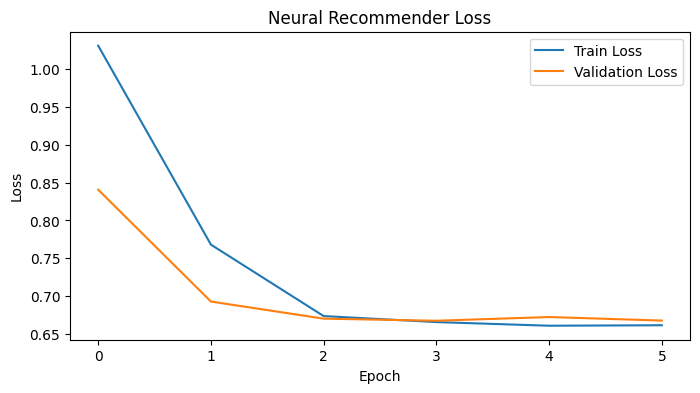

Neural recommender RMSE: 0.8169


In [30]:
try:
    import tensorflow as tf
    from tensorflow.keras.layers import Input, Dense, Concatenate
    from tensorflow.keras.models import Model
    from tensorflow.keras.callbacks import EarlyStopping
    from sklearn.model_selection import train_test_split

    nn_sample_pd["genre_list"] = nn_sample_pd["genres_clean"].fillna("Unknown").str.split("|")
    all_genres = sorted({g for lst in nn_sample_pd["genre_list"] for g in lst if g})
    genre_to_idx = {g: i for i, g in enumerate(all_genres)}

    def multi_hot(genres):
        vec = np.zeros(len(all_genres), dtype=np.float32)
        for g in genres:
            if g in genre_to_idx:
                vec[genre_to_idx[g]] = 1.0
        return vec

    nn_sample_pd["genre_vec"] = nn_sample_pd["genre_list"].apply(multi_hot)

    year_min = nn_sample_pd["year"].dropna().min()
    year_max = nn_sample_pd["year"].dropna().max()
    nn_sample_pd["year"] = nn_sample_pd["year"].fillna(year_min)
    nn_sample_pd["year_norm"] = (nn_sample_pd["year"] - year_min) / (year_max - year_min + 1e-9)
    nn_sample_pd["avg_rating_norm"] = (nn_sample_pd["movie_avg_rating"] - 0.5) / 4.5

    X_movie = np.stack([
        np.concatenate([g, np.array([y, a], dtype=np.float32)])
        for g, y, a in zip(nn_sample_pd["genre_vec"], nn_sample_pd["year_norm"], nn_sample_pd["avg_rating_norm"])
    ])

    user_avg_map_small = nn_sample_pd.groupby("userId")["rating"].mean().to_dict()
    X_user = np.array([[user_avg_map_small[u]] for u in nn_sample_pd["userId"]], dtype=np.float32)
    y = nn_sample_pd["rating"].astype(np.float32).values

    X_user_train, X_user_val, X_movie_train, X_movie_val, y_train, y_val = train_test_split(
        X_user, X_movie, y, test_size=0.2, random_state=42
    )

    user_input = Input(shape=(X_user.shape[1],))
    u = Dense(16, activation="relu")(user_input)

    movie_input = Input(shape=(X_movie.shape[1],))
    m = Dense(64, activation="relu")(movie_input)
    m = Dense(32, activation="relu")(m)

    x = Concatenate()([u, m])
    x = Dense(64, activation="relu")(x)
    x = Dense(32, activation="relu")(x)
    output = Dense(1, activation="linear")(x)

    nn_model = Model(inputs=[user_input, movie_input], outputs=output)
    nn_model.compile(optimizer="adam", loss="mse", metrics=["mae"])

    early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

    history = nn_model.fit(
        [X_user_train, X_movie_train],
        y_train,
        validation_data=([X_user_val, X_movie_val], y_val),
        epochs=10,
        batch_size=512,
        verbose=1,
        callbacks=[early_stop]
    )

    nn_val_pred = np.clip(nn_model.predict([X_user_val, X_movie_val], verbose=0).ravel(), 0.5, 5.0)
    nn_rmse = rmse_score(y_val.tolist(), nn_val_pred.tolist())

    plt.figure(figsize=(8, 4))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.legend()
    plt.title("Neural Recommender Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    print("Neural recommender RMSE:", round(nn_rmse, 4))

except Exception as e:
    print("Neural section skipped:", e)
    nn_rmse = None

## Task 9: Reinforcement Learning in Recommender Systems

In [31]:
popular_movies_rl = [r["movieId"] for r in train_ratings.groupBy("movieId").count().orderBy(F.desc("count")).limit(200).collect()]
rl_pd = ratings_raw.filter(F.col("movieId").isin(popular_movies_rl)).select("userId", "movieId", "rating").limit(200000).toPandas()

reward_table = {}
for row in rl_pd.itertuples(index=False):
    reward_table.setdefault(row.userId, {})
    reward_table[row.userId][row.movieId] = 1 if row.rating >= POSITIVE_THRESHOLD else 0

users_seq = list(rl_pd["userId"].drop_duplicates())[:500]

In [32]:
class EpsilonGreedyBandit:
    def __init__(self, arms, epsilon=0.1):
        self.arms = arms
        self.epsilon = epsilon
        self.counts = {a: 0 for a in arms}
        self.values = {a: 0.0 for a in arms}

    def choose(self):
        if random.random() < self.epsilon:
            return random.choice(self.arms)
        return max(self.arms, key=lambda a: self.values[a])

    def update(self, arm, reward):
        self.counts[arm] += 1
        n = self.counts[arm]
        self.values[arm] += (reward - self.values[arm]) / n

eg = EpsilonGreedyBandit(popular_movies_rl, 0.1)
eg_rewards = []
total = 0

for uid in users_seq:
    arm = eg.choose()
    reward = reward_table.get(uid, {}).get(arm, 0)
    eg.update(arm, reward)
    total += reward
    eg_rewards.append(total)

epsilon_greedy_avg_reward = total / len(users_seq)
print("Epsilon-Greedy average reward:", round(epsilon_greedy_avg_reward, 4))

Epsilon-Greedy average reward: 0.36


# Part 6: Explainability in Recommender Systems

## Task 10–13: Explanation and Summary

# Final Comparison and Summary

In [33]:
results = []

results.append({
    "model": "Content TF-IDF User Profile",
    "rmse": None,
    "precision@5": content_p5,
    "recall@5": content_r5,
    "notes": "Spark TF-IDF + local bounded recommendation scoring"
})

best_user_cf_row = user_cf_metrics_df.sort_values(["rmse", "precision@5"], ascending=[True, False]).iloc[0]
results.append({
    "model": f"User-CF (k={int(best_user_cf_row['k'])})",
    "rmse": float(best_user_cf_row["rmse"]),
    "precision@5": float(best_user_cf_row["precision@5"]),
    "recall@5": float(best_user_cf_row["recall@5"]),
    "notes": "Reduced active subset"
})

best_item_cf_row = item_cf_metrics_df.sort_values(["rmse", "precision@5"], ascending=[True, False]).iloc[0]
results.append({
    "model": f"Item-CF (k={int(best_item_cf_row['k'])})",
    "rmse": float(best_item_cf_row["rmse"]),
    "precision@5": float(best_item_cf_row["precision@5"]),
    "recall@5": float(best_item_cf_row["recall@5"]),
    "notes": "Reduced active subset"
})

results.append({
    "model": f"Manual SVD (k={max_k})",
    "rmse": float(svd_rmse),
    "precision@5": float(svd_p5),
    "recall@5": float(svd_r5),
    "notes": "Local reduced matrix only"
})

results.append({
    "model": "Spark ALS",
    "rmse": float(als_rmse),
    "precision@5": None,
    "recall@5": None,
    "notes": "Scalable factorization"
})

results.append({
    "model": "Meta-Learning Hybrid",
    "rmse": float(hybrid_meta_rmse),
    "precision@5": float(hybrid_meta_p5),
    "recall@5": float(hybrid_meta_r5),
    "notes": "Bounded local meta-model over Spark-prepared features"
})

if nn_rmse is not None:
    results.append({
        "model": "Neural Recommender",
        "rmse": float(nn_rmse),
        "precision@5": None,
        "recall@5": None,
        "notes": "Spark-prepared sampled local training"
    })

comparison_df = pd.DataFrame(results)
display(comparison_df)

,model,rmse,precision@5,recall@5,notes
0,Content TF-IDF User Profile,NaN,0.060000,0.004024,Spark TF-IDF + local bounded recommendation sc...
1,User-CF (k=30),0.826692,0.370000,0.019599,Reduced active subset
2,Item-CF (k=20),0.843330,0.440000,0.023621,Reduced active subset
3,Manual SVD (k=40),0.884152,0.310000,0.017105,Local reduced matrix only
4,Spark ALS,0.873574,NaN,NaN,Scalable factorization
5,Meta-Learning Hybrid,0.801624,0.433333,0.028326,Bounded local meta-model over Spark-prepared f...
6,Neural Recommender,0.816939,NaN,NaN,Spark-prepared sampled local training
